In [ ]:
# imports i neteja

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# llistem les stats

In [3]:
import seaborn as sns
sns.set(style="darkgrid")

df = pd.read_csv('PokemonData.csv')
stats = ['HP','Attack','Defense','SpAtk','SpDef','Speed']
df['Total'] = df[stats].sum(axis=1)

In [ ]:
# creem la columna Total: suma de les 6 estadístiques de cada Pokémon (axis=1 = sumar per files) 

In [ ]:
# fem un fill a la fila on no hi ha un segon tipus i posem NaN, en comptes de deixar-lo buit

In [ ]:
df['TipusDual'] = df['Type2'].notna()
df['Type2'] = df['Type2'].fillna('Cap')

In [ ]:
# assignem com a duplicat per no comptar de mes, les formes especials dels pokemon (megaevo, formes primigenies etc...)

In [4]:
df['FormaAlterna'] = df['Num'].duplicated()

In [ ]:
# pasem legendary a text llegible per poder fer els gràfics

In [5]:
df['Categoria'] = df['Legendary'].map({True: 'Llegendari', False: 'Normal'})

df.head()

,Num,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary,Total,FormaAlterna,Categoria
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,318,False,Normal
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,405,False,Normal
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,525,False,Normal
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,625,True,Normal
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,309,False,Normal


In [ ]:
# explorem les dades

In [15]:
print(df.shape)                
print(df.dtypes)               
print(df.isna().sum())         
print('Formes alternes:', df['FormaAlterna'].sum())    
print('Files duplicades:', df.duplicated().sum())      
df.describe().round(1)                 

(800, 15)
Num             int64
Name              str
Type1             str
Type2             str
HP              int64
Attack          int64
Defense         int64
SpAtk           int64
SpDef           int64
Speed           int64
Generation      int64
Legendary        bool
Total           int64
FormaAlterna     bool
Categoria         str
dtype: object
Num               0
Name              0
Type1             0
Type2           386
HP                0
Attack            0
Defense           0
SpAtk             0
SpDef             0
Speed             0
Generation        0
Legendary         0
Total             0
FormaAlterna      0
Categoria         0
dtype: int64
Formes alternes: 79
Files duplicades: 0


,Num,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Total
count,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0
mean,362.8,69.3,79.0,73.8,72.8,71.9,68.3,3.3,435.1
std,208.3,25.5,32.5,31.2,32.7,27.8,29.1,1.7,120.0
min,1.0,1.0,5.0,5.0,10.0,20.0,5.0,1.0,180.0
25%,184.8,50.0,55.0,50.0,49.8,50.0,45.0,2.0,330.0
50%,364.5,65.0,75.0,70.0,65.0,70.0,65.0,3.0,450.0
75%,539.2,80.0,100.0,90.0,95.0,90.0,90.0,5.0,515.0
max,721.0,255.0,190.0,230.0,194.0,230.0,180.0,6.0,780.0


In [ ]:
# Pregunta:HA PUJAT EL PODER DELS POKEMON AMB LES GENERACIONS? (power creep) 

In [ ]:
# deixo significat de power creep per si acas::::

In [ ]:
# El power creep (o augment de poder) és el fenomen pel qual les noves generacions de Pokémon introdueixen espècies, 
# habilitats o mecàniques més fortes que les anteriors, tornant obsolets als Pokémon més antics

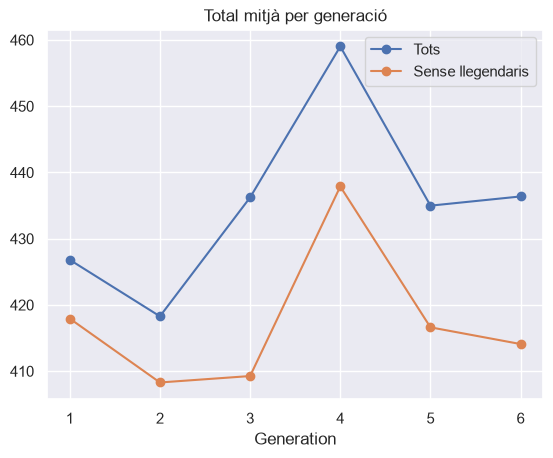

In [13]:
df.groupby('Generation')['Total'].mean().plot(marker='o', label='Tots')
# Nomes fem pokemons normals perque els llegendaris tenen stats exageradament altes, no serveixen per aixo
df[df['Categoria']=='Normal'].groupby('Generation')['Total'].mean().plot(marker='o', label='Sense llegendaris')
plt.title('Total mitjà per generació')
plt.legend()                                
plt.show()